In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# A instrução Try deve ter pelo menos uma cláusula except.
try: 
    df = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', encoding='iso-8859-1', sep=';')
    # encoding = 'latin1'
    # encoding = 'IBM860'
    # encoding = 'iso-8859-1'
    # print(df.head())
    print(df.columns)
except Exception as e:
    print(f'Erro: {e}')

Index(['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc',
       'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli',
       'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom',
       'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa',
       'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua',
       'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia',
       'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque',
       'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos',
       'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular',
       'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro',
       'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas',
       'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor',
       'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca',
       'pessoas_desaparecidas'

In [3]:
# agrupar
# filtrar
df_roubo_veiculos = df[['munic', 'roubo_veiculo']]
# após verificar e fazer a filtragem o ideal é comentar esse print para evitar de ficar toda hora print(df_roubo_veiculos.head())
# agrupar por municipio
df_roubo_veiculos = df_roubo_veiculos.groupby('munic').sum().reset_index().sort_values(by='roubo_veiculo', ascending=False)
# normalmente a ordenação costuma ser do maior para o menor (ascending=False)
df_roubo_veiculos

,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
...,...,...
66,Rio das Flores,8
58,Porciúncula,7
46,Natividade;Varre-Sai,6
45,Miracema,6


In [4]:
# Ao invés de usar o Pandas,vamos criar um array do Numpy.
# Com bases de dados robustas, o Numpy pode ser mais eficiente.
# Transformar data frame em Array
roubo_veiculo_array = np.array(df_roubo_veiculos['roubo_veiculo'])
amplitude = np.max(roubo_veiculo_array) - np.min(roubo_veiculo_array)
media_roubos = np.mean(roubo_veiculo_array)
mediana_roubos = np.median(roubo_veiculo_array)
# pacote de dispersão e posição
q1 = np.quantile(roubo_veiculo_array, 0.25)
q2 = np.quantile(roubo_veiculo_array, 0.50)
q3 = np.quantile(roubo_veiculo_array, 0.75)
# criar recortes com os outliers
iqr = q3 - q1
# limite superior -> identificar outliers acima de q3
limite_superior = q3 + 1.5 * iqr
# limite inferior -> identificar outliers abaixo de q1
limite_inferior = q1 - 1.5 * iqr
# Pacote de dispersão
desvio = np.std(roubo_veiculo_array)
variancia = np.var(roubo_veiculo_array)
distancia_var_media = abs(variancia/media_roubos**2)
cv = desvio/media_roubos

assimetria = df_roubo_veiculos['roubo_veiculo'].skew()
kurt = df_roubo_veiculos['roubo_veiculo'].kurtosis()


In [5]:
print(f'Média: {media_roubos}')
print(f'Mediana: {mediana_roubos}')
print(f'Min: {np.min(roubo_veiculo_array)}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Q1: {q1}')
print(f'Q2: {q2}')
print(f'Q3: {q3}')
print(f'Limite Superior: {limite_superior}')
print(f'Max: {np.max(roubo_veiculo_array)}')
print(f'Distancia Variancia: {distancia_var_media}')
print(f'Desvio Padrão: {desvio}')
print(f'Coeficiente de Variação: {cv}')
print(f'Assimetria: {assimetria}')
print(f'Curtose: {kurt}')

Média: 7448.2444444444445
Mediana: 247.5
Min: 2
Limite Inferior: -1366.75
Q1: 47.0
Q2: 247.5
Q3: 989.5
Limite Superior: 2403.25
Max: 372584
Distancia Variancia: 28.90540358042223
Desvio Padrão: 40044.55206622608
Coeficiente de Variação: 5.376374575903565
Assimetria: 8.617034541386754
Curtose: 78.21644464221471


In [6]:
# Criar dois novos data frames para verificar se há ouliers de quais cidades ocorrem mais roubos
df_roubo_outliers_inferiores = df_roubo_veiculos[df_roubo_veiculos['roubo_veiculo'] < limite_inferior]
df_roubo_outliers_superiores = df_roubo_veiculos[df_roubo_veiculos['roubo_veiculo'] > limite_superior]
# outliers inferiores
if df_roubo_outliers_inferiores.empty:
    print("Não há outliers inferiores")
else:
    print(df_roubo_outliers_inferiores.sort_values(by='roubo_veiculo', ascending=False))

df_roubo_outliers_superiores = df_roubo_veiculos[df_roubo_veiculos['roubo_veiculo'] < limite_inferior]
df_roubo_outliers_superiores = df_roubo_veiculos[df_roubo_veiculos['roubo_veiculo'] > limite_superior]
# outliers superiores
if df_roubo_outliers_superiores.empty:
    print("Não há outliers superiores")
else:
    print(df_roubo_outliers_superiores.sort_values(by='roubo_veiculo', ascending=False))

Não há outliers inferiores
                    munic  roubo_veiculo
68         Rio de Janeiro         372584
23        Duque de Caxias          62574
78            São Gonçalo          52539
50            Nova Iguaçu          40235
81     São João de Meriti          30151
6            Belford Roxo          22417
48                Niterói          21646
47              Nilópolis          11952
43               Mesquita           7825
27               Itaboraí           5914
29                Itaguaí           3921
38                   Magé           3342
36                  Macaé           3248
13  Campos dos Goytacazes           3022
41                 Maricá           2663


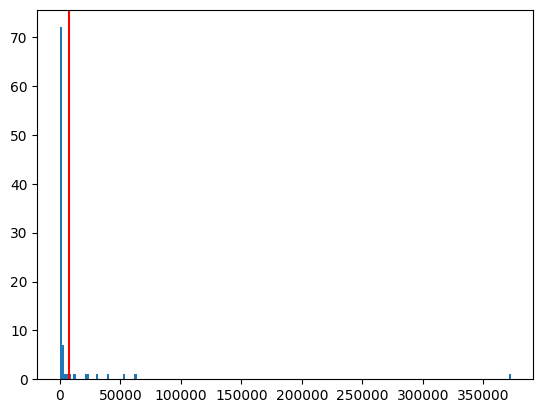

In [7]:
# Histograma
plt.hist(roubo_veiculo_array, bins=200)
plt.axvline(x=media_roubos, color='red')
# se fosse num arquivo em python no final seria necessário usar o comando plt.show()


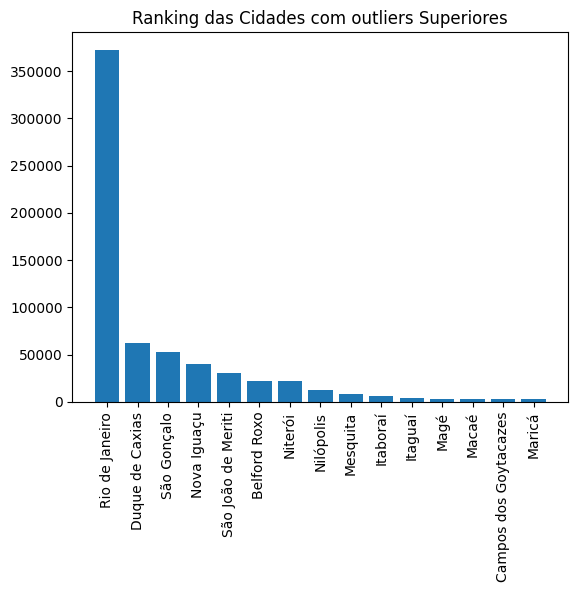

In [8]:
plt.bar(df_roubo_outliers_superiores['munic'], df_roubo_outliers_superiores['roubo_veiculo'])
plt.xticks(rotation=90)
plt.title('Ranking das Cidades com outliers Superiores')
plt.show()


{'whiskers': [<matplotlib.lines.Line2D at 0x1d665e0b450>,
 'caps': [<matplotlib.lines.Line2D at 0x1d665bc8650>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d665e01b10>],
 'medians': [<matplotlib.lines.Line2D at 0x1d665bc9710>],
 'fliers': [],
 'means': [<matplotlib.lines.Line2D at 0x1d665bca090>]}

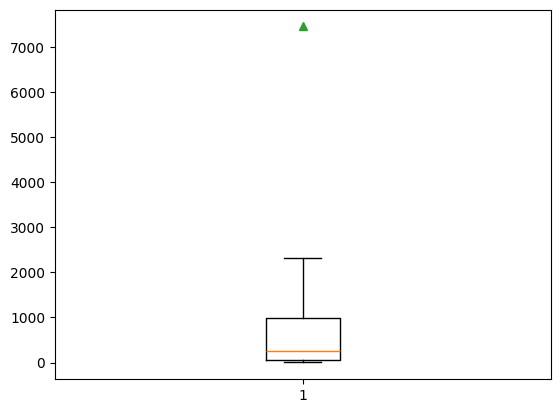

In [9]:
# Showmeans (true or false) -> true mostra a média
# Showfliers (true or false) -> true mostra outliers
plt.boxplot(roubo_veiculo_array, vert=True, showmeans=True, showfliers=False)

In [10]:
# Agrupamento e Analise
# Data de conclusão 9 de março de 2026 às 16:00
# Instruções
# Análise de Recuperação de Veículos
# Utilize a mesma base de dados 03.BaseDPEvolucaoMensalCisp.csv usada anteriormente na análise de roubo de veículos. 
# Nesta atividade você irá investigar quantos veículos foram recuperados e identificar qual ano teve a maior quantidade de recuperações.

# 1. Quantidade de veículos recuperados por município
# Crie um novo script em Python ou adapte o código já utilizado na análise de roubo de veículos.

# Passos
#Importe as bibliotecas necessárias.

# Carregue o arquivo CSV usando pandas.

# Selecione apenas as colunas:

# munic, recuperacao_veiculos
# Agrupe os dados por município.
# Some o total de veículos recuperados.
# Ordene os resultados do maior para o menor.
# Exiba os 10 municípios com maior número de veículos recuperados.
# 
# Perguntas para responder
# Existe grande diferença entre os primeiros municípios do ranking?
# Compare com o ranking de roubo de veículos. O município que mais tem roubos também lidera em recuperações?



In [11]:
# 2. Análise por ano - Recuperação de veículos
df_recup_ano = (
    df[['ano', 'recuperacao_veiculos']]
    .groupby('ano', as_index=False)['recuperacao_veiculos']
    .sum()
    .sort_values(by='recuperacao_veiculos', ascending=False)
    .reset_index(drop=True)
 )
display(df_recup_ano)

# Perguntas: ano com maior recuperação
ano_max = df_recup_ano.loc[0, 'ano']
valor_max = df_recup_ano.loc[0, 'recuperacao_veiculos']
print(f'Ano com maior recuperação: {ano_max} (Total: {valor_max})')

# Tendência ao longo dos anos
df_recup_ano_ord = df_recup_ano.sort_values('ano').reset_index(drop=True)
variacao = df_recup_ano_ord['recuperacao_veiculos'].diff()
if (variacao.dropna() >= 0).all():
    tendencia = 'crescimento contínuo'
elif (variacao.dropna() <= 0).all():
    tendencia = 'queda contínua'
else:
    tendencia = 'tendência mista (altas e baixas)'
print(f'Tendência: {tendencia}')

# Comparação com roubos por ano
df_roubo_ano = (
    df[['ano', 'roubo_veiculo']]
    .groupby('ano', as_index=False)['roubo_veiculo']
    .sum()
    .sort_values('ano')
    .reset_index(drop=True)
 )
df_comp = df_recup_ano_ord.merge(df_roubo_ano, on='ano', how='inner')
corr = df_comp['recuperacao_veiculos'].corr(df_comp['roubo_veiculo'])
print(f'Correlação recuperação x roubo por ano: {corr:.2f}')
if corr >= 0.5:
    print('Comportamento acompanha o crescimento/queda dos roubos (correlação positiva).')
elif corr <= -0.5:
    print('Comportamento inverso aos roubos (correlação negativa).')
else:
    print('Sem relação clara com os roubos (correlação fraca).')

,ano,recuperacao_veiculos
0,2017,37630
1,2018,36448
2,2003,29947
3,2016,28690
4,2019,26863
5,2004,26522
6,2005,26332
7,2006,26073
8,2014,25227
9,2007,24452


Ano com maior recuperação: 2017 (Total: 37630)
Tendência: tendência mista (altas e baixas)
Correlação recuperação x roubo por ano: 0.94
Comportamento acompanha o crescimento/queda dos roubos (correlação positiva).


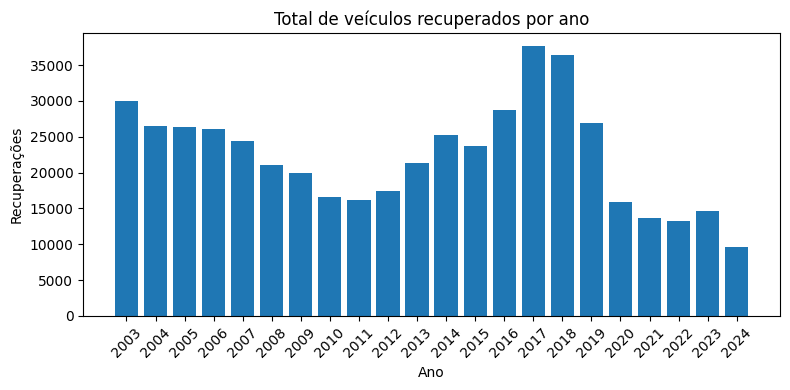

In [12]:
# 3. Visualização - Total de recuperações por ano
plt.figure(figsize=(8, 4))
plt.bar(df_recup_ano_ord['ano'].astype(str), df_recup_ano_ord['recuperacao_veiculos'])
plt.title('Total de veículos recuperados por ano')
plt.xlabel('Ano')
plt.ylabel('Recuperações')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Outliers - municípios com recuperação muito acima/abaixo da média
df_recup_munic = (
    df[['munic', 'recuperacao_veiculos']]
    .groupby('munic', as_index=False)['recuperacao_veiculos']
    .sum()
    .sort_values(by='recuperacao_veiculos', ascending=False)
    .reset_index(drop=True)
 )

recup_array = df_recup_munic['recuperacao_veiculos'].to_numpy()
q1_r = np.quantile(recup_array, 0.25)
q3_r = np.quantile(recup_array, 0.75)
iqr_r = q3_r - q1_r
limite_inf_r = q1_r - 1.5 * iqr_r
limite_sup_r = q3_r + 1.5 * iqr_r

outliers_inf = df_recup_munic[df_recup_munic['recuperacao_veiculos'] < limite_inf_r]
outliers_sup = df_recup_munic[df_recup_munic['recuperacao_veiculos'] > limite_sup_r]

print('Outliers inferiores (municípios muito abaixo da média):')
display(outliers_inf)
print('Outliers superiores (municípios muito acima da média):')
display(outliers_sup)

Outliers inferiores (municípios muito abaixo da média):


,munic,recuperacao_veiculos


Outliers superiores (municípios muito acima da média):


,munic,recuperacao_veiculos
0,Rio de Janeiro,269057
1,Duque de Caxias,42959
2,São Gonçalo,39574
3,São João de Meriti,19341
4,Nova Iguaçu,17217
5,Niterói,15417
6,Belford Roxo,14164
7,Campos dos Goytacazes,5334
8,Nilópolis,5257
9,Mesquita,5000


A análise começa com a distribuição dos roubos por município, revelando concentração: poucos municípios respondem por uma grande parcela dos casos. As medidas de posição (média, mediana) e dispersão (desvio, variância, IQR) mostram uma distribuição assimétrica, com cauda longa — sinal de desigualdade entre localidades. Os boxplots e outliers reforçam isso: existem municípios muito acima do padrão, sugerindo fatores estruturais (densidade urbana, fluxo de veículos, infraestrutura policial) que elevam tanto roubos quanto recuperações.

Ao migrar para a recuperação de veículos por ano, a soma anual expõe o ritmo histórico das recuperações. O ano com maior total indica o pico de eficiência ou intensidade operacional. A tendência temporal (crescimento contínuo, queda ou oscilação) descreve o comportamento do sistema ao longo do tempo e pode refletir mudanças em políticas públicas, tecnologia de rastreamento ou capacidade investigativa.

A comparação com roubos por ano ajuda a interpretar se as recuperações acompanham a dinâmica criminal. Correlação positiva sugere que, quando os roubos aumentam, as recuperações também sobem — possivelmente por maior esforço operacional ou porque há mais veículos para recuperar. Correlação fraca ou negativa indicaria desconexão entre ocorrência e resposta.

O gráfico de barras por ano torna esse padrão visual: picos apontam anos de maior recuperação, enquanto quedas podem sugerir retração operacional, mudanças de tipificação ou subnotificação. Para interpretação, é útil relacionar esses picos a eventos externos (políticas, crise econômica, mudanças institucionais).

Por fim, a análise de outliers por município em recuperação mostra extremos: cidades muito acima da média podem ser polos de recuperação (centros de desmanche combatidos, ações específicas), enquanto valores muito baixos podem indicar baixa efetividade, menor frota ou subregistro. Isso orienta hipóteses e prioriza investigações locais.